# Quality toolbox

In [1]:
# Import library needed
import functions
import numpy as np
import matplotlib.pyplot as plt

## Load data and parameters

In [2]:
# Parameters of the session you analyze

# Name or number of the subject you analyze
sub = 'sub-123'
# Name of the session you analyze
sess = 'screening1'

In [3]:
# Path to data - This is the only thing you have to change to run the script


# Path where your micro data are stored (.dat, .medd, .nsX, .ncs)
dataFolder=r'F:\Screening\database\sub-123\sess-1\ncs' 

# Path where you want to store figures and results
saveFolder=r'F:\Screening\results\sub-123\screening1\quality_data/'

# path to excel file for the RMS tracking, only one excel is used per patient, all RMS data for the SEEG will be trancked on a single file

trackingtbl ='F:/Screening/results/Quality/sub-123-tracking.xlsx'


In [4]:
# Load data (we load in raw format with neo and MNE)
# Give in entry the path folder where the ncs files of micro-electrodes are stored
raw_data, data = functions.load_raw_data(dataFolder,dtype='ncs',length=5)

Checking files in F:\Screening\database\sub-123\sess-1\ncs
Ignoring .ncs files:

Checking for temporal discontinuities in Neo data segments.
N = 293 discontinuous Neo segments detected with delta > 4.57763671875e-05 sec. Annotating gaps as BAD_ACQ_SKIP.


In [6]:
# Determine parameters from the recording
sr = int(raw_data.info['sfreq'])
print("Your recording has a sampling rate of: " + str(sr) +" Hz")

Your recording has a sampling rate of: 32768 Hz


In [7]:
duration_min  = int(raw_data.__len__()/sr/60)

print("L'enregistrement a duré : "+str(duration_min)+" minutes")

L'enregistrement a duré : 5 minutes


In [8]:
# Display the name of your electrodes

chRegions = np.array(raw_data.ch_names)
print(chRegions)

['db1' 'db2' 'db3' 'db4' 'db5' 'db6' 'db7' 'db8' 'dtb1' 'dtb2' 'dtb3'
 'dtb4' 'dtb5' 'dtb6' 'dtb7' 'dtb8' 'dtp1' 'dtp2' 'dtp3' 'dtp4' 'dtp5'
 'dtp6' 'dtp7' 'dtp8' 'va1' 'va2' 'va3' 'va4' 'va5' 'va6' 'va7' 'va8'
 'vft1' 'vft2' 'vft3' 'vft4' 'vft5' 'vft6' 'vft7' 'vft8' 'vtp1' 'vtp2'
 'vtp3' 'vtp4' 'vtp5' 'vtp6' 'vtp7' 'vtp8']


In [9]:
# Re-order channels and data if there is more than two tetrode on a shaft
chRegions, data = functions.reorder_data(chRegions,data)

print(chRegions)

['db1' 'db2' 'db3' 'db4' 'db5' 'db6' 'db7' 'db8' 'dtb1' 'dtb2' 'dtb3'
 'dtb4' 'dtb5' 'dtb6' 'dtb7' 'dtb8' 'dtp1' 'dtp2' 'dtp3' 'dtp4' 'dtp5'
 'dtp6' 'dtp7' 'dtp8' 'va1' 'va2' 'va3' 'va4' 'va5' 'va6' 'va7' 'va8'
 'vft1' 'vft2' 'vft3' 'vft4' 'vft5' 'vft6' 'vft7' 'vft8' 'vtp1' 'vtp2'
 'vtp3' 'vtp4' 'vtp5' 'vtp6' 'vtp7' 'vtp8']


## Quality analysis of the signal

In [29]:
# Get the power spectrum for each channel

p_spectrum = []
for iCh in range(data.shape[0]):
    pxx, f_plot = functions.p_welch(data[iCh],sr=sr,sr_down=4,fr_low=1,fr_high=600)

    p_spectrum.append(pxx)
    


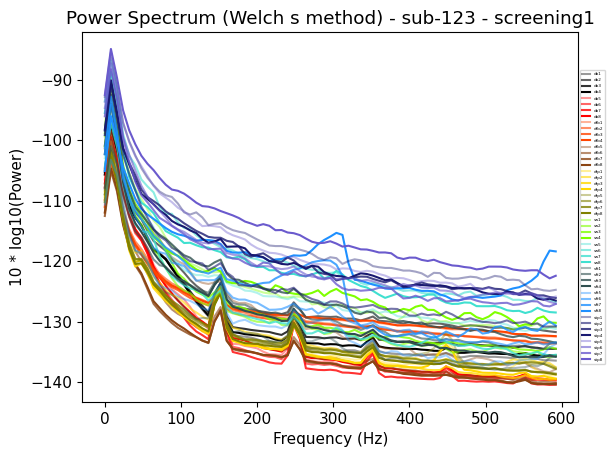

In [30]:
# Plot the results of PSD for each channel
functions.plot_all_chan(f_plot,nCh=len(chRegions),chRegs=chRegions,psd=p_spectrum,bsnm=sub,session_screening=str(sess),saveFolder=saveFolder)

In [31]:
# Get the level of noise of the recording for each channel

for iCh in range(data.shape[0]):
    functions.plot_noise(data[iCh],sr=int(sr),num_channel=iCh,name_channels=chRegions[iCh],path=saveFolder)



In [32]:
# get the RMS for each channel 
#prep RMS tracking excel file 

functions.tblprep(trackingtbl,chRegions,sub,sess)


for iCh in range(data.shape[0]):
    functions.rms_signal(data[iCh],trackingtbl,chRegions[iCh],sub,sess)


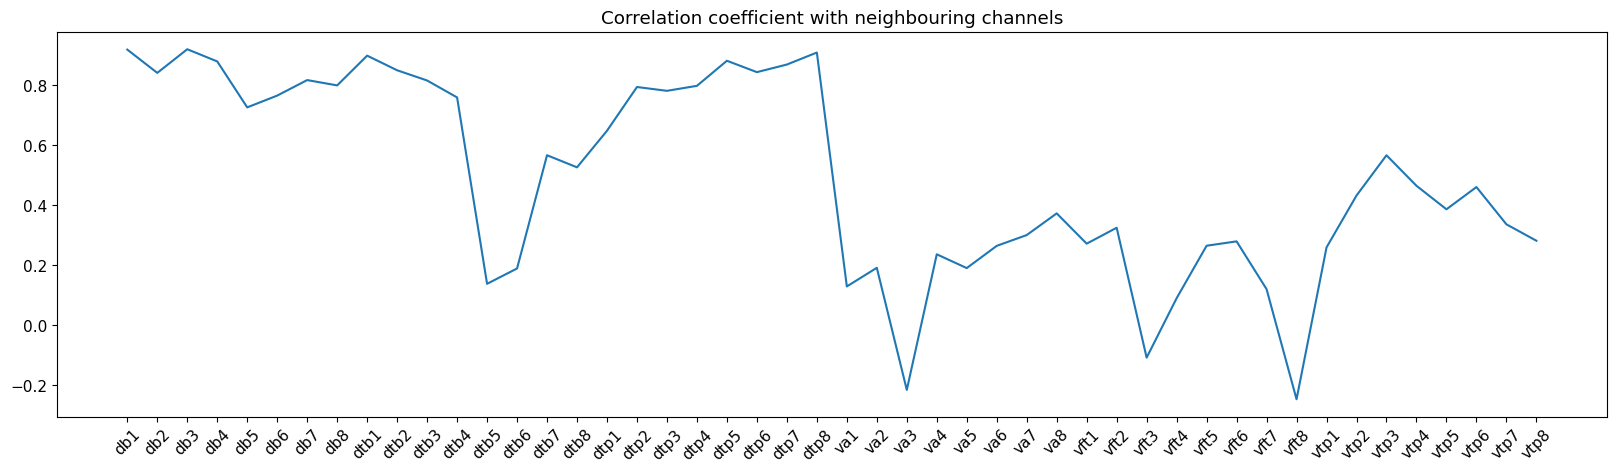

In [33]:
# Compute correlation between neighbouring channels

functions.correlation_coefficient(data,chRegions,saveFolder,trackingtbl,sub,sess)

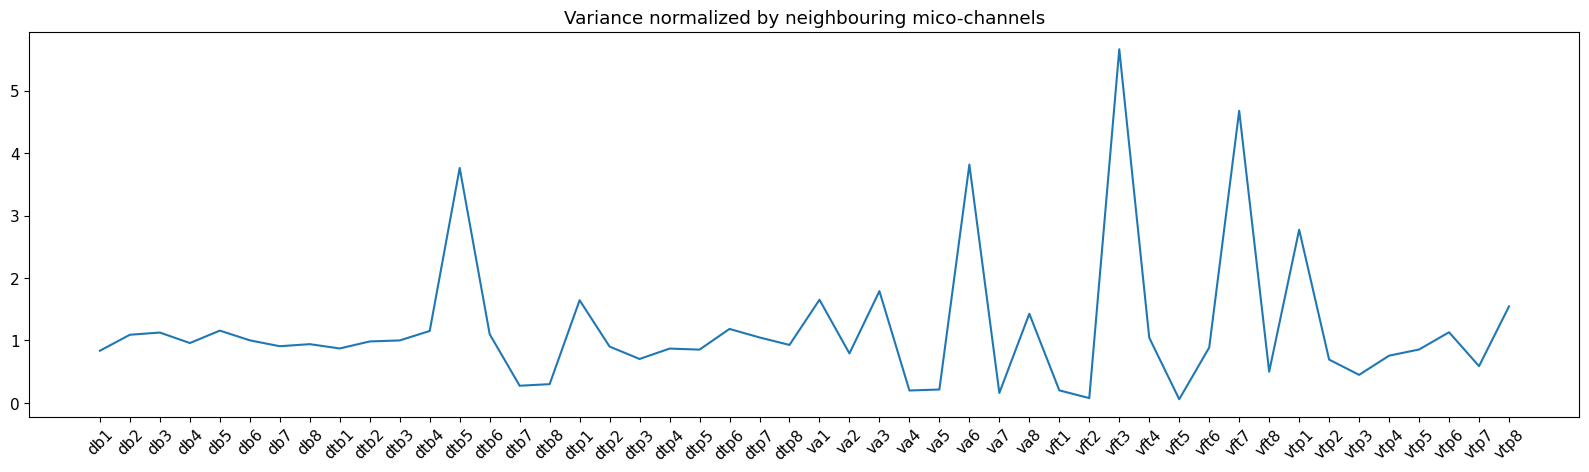

In [34]:
# Compute variance normalized by variance of neighbouring channels
functions.variance_normalized(data,chRegions,saveFolder,trackingtbl,sub,sess)

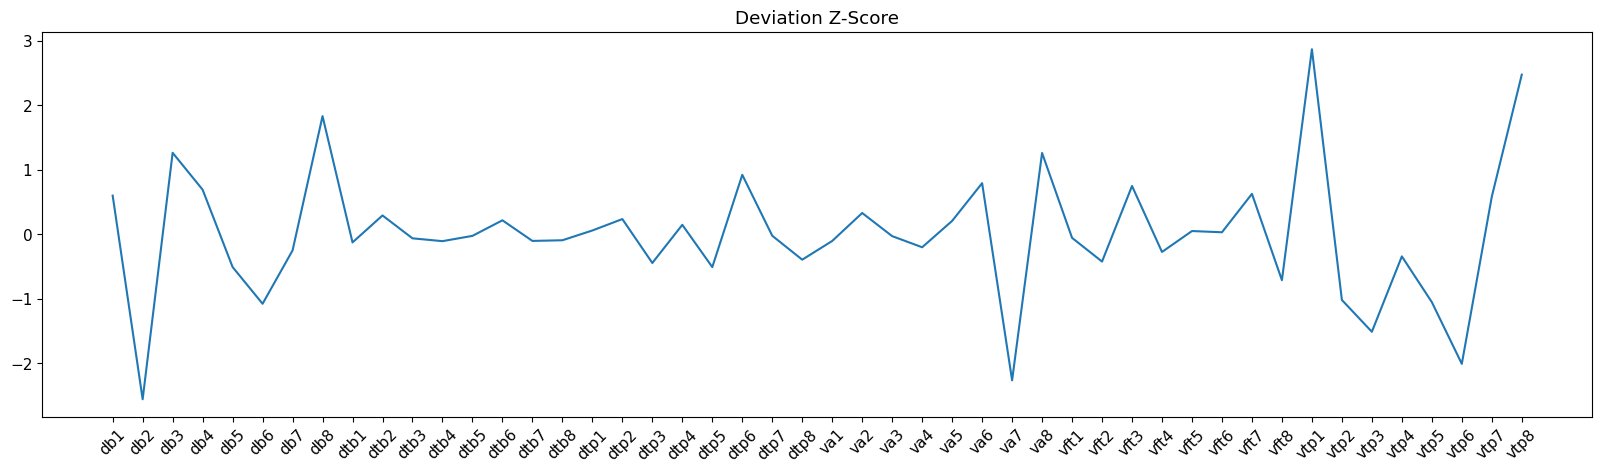

In [35]:
functions.deviation(data,chRegions,saveFolder,trackingtbl,sub,sess)

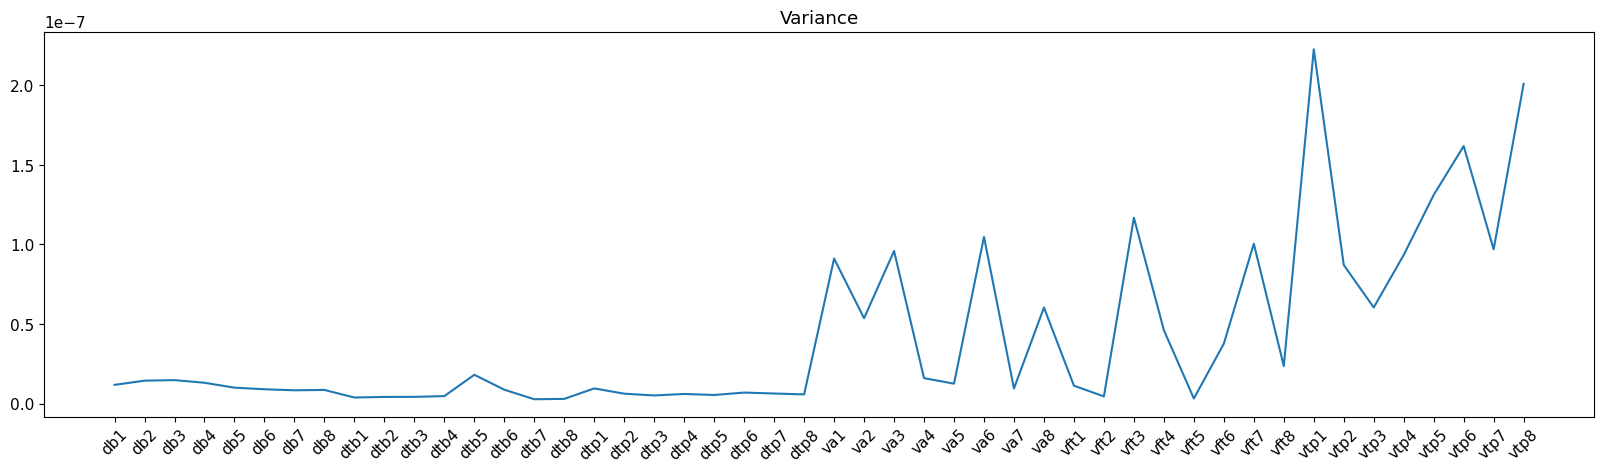

In [36]:
functions.variance(data,chRegions,saveFolder,trackingtbl,sub,sess)

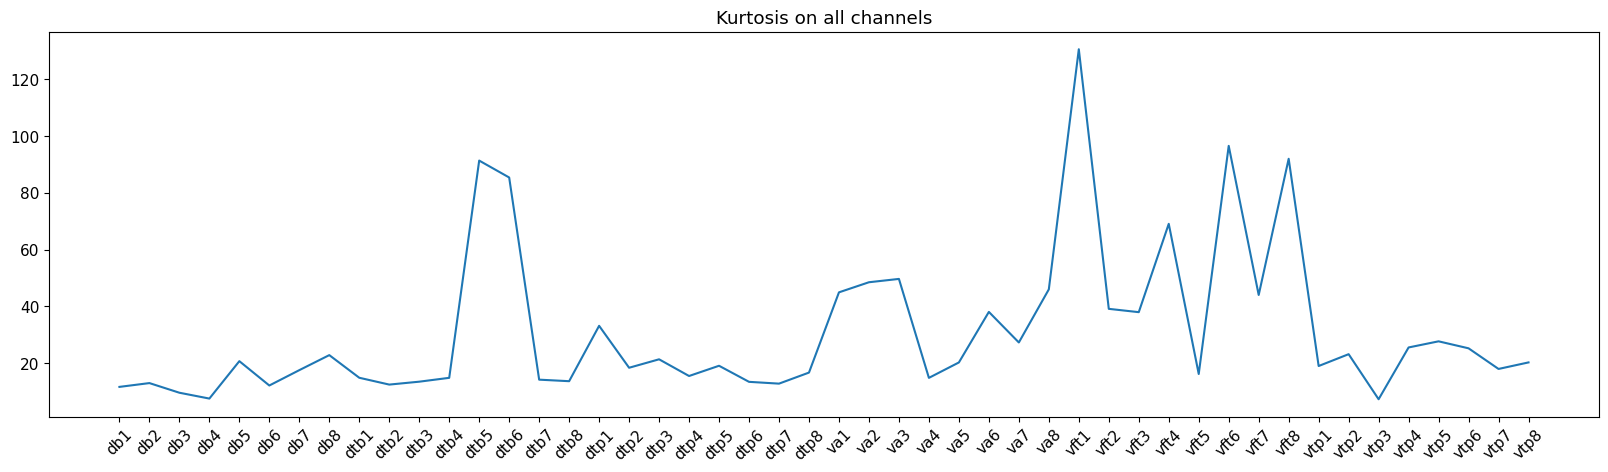

In [37]:
functions.kurtosis(data,chRegions,saveFolder,trackingtbl,sub,sess)

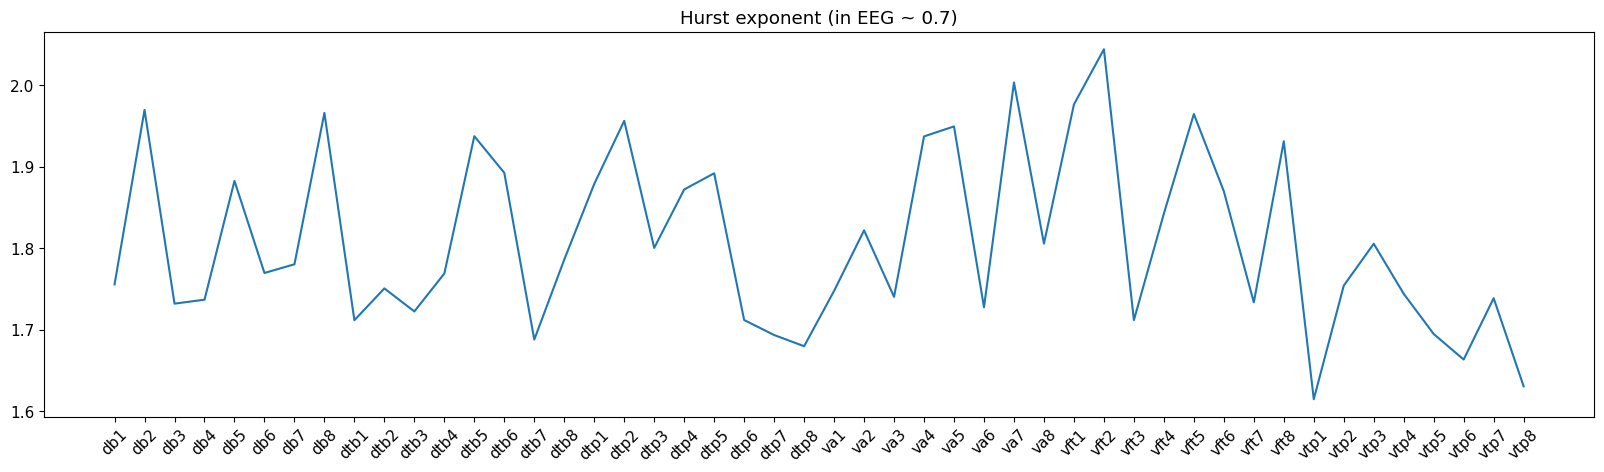

In [38]:
functions.hurst_component(data,chRegions,saveFolder)

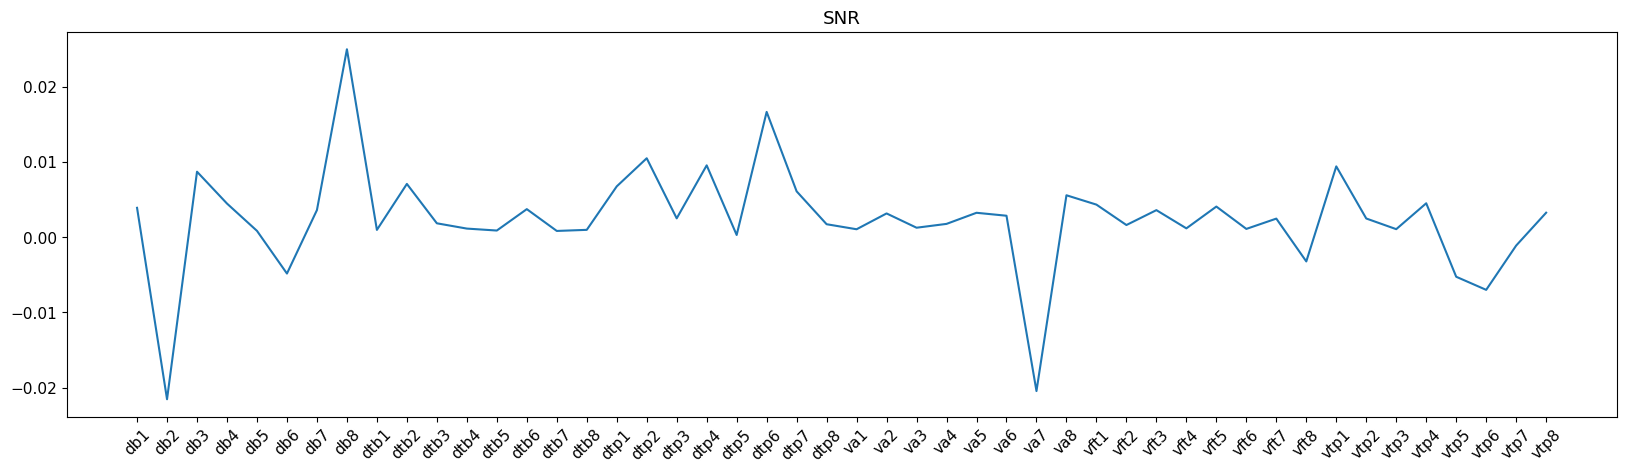

In [39]:
SNR = functions.signaltonoise(data,chRegions,saveFolder,trackingtbl,sub,sess)

# Part below still on test

# Cognitive analyses of experiment

In [2]:
# Create epoch objects

epoch = functions.create_epoch(dataFolder,t_min=-1,t_max=1)

NameError: name 'dataFolder' is not defined

In [11]:
epoch = epoch.get_data()

Loading data for 808 events and 65537 original time points ...
137 bad epochs dropped


In [12]:
np.save(r'F:\Screening\database\sub-123\sess-1\epoch/epoch_micro.npy',epoch)

In [2]:
epoch_data = np.load(r'F:\Screening\database\sub-123\sess-1\epoch/epoch_micro.npy')

In [3]:
functions.plot_artefact_map(epoch_data=epoch_data,nCh=48,path='C:/Users/dornier/PhD/Quality_Data/')

In [11]:
np.shape(epoch_data)

(671, 48, 65537)

In [ ]:
def plot_artefact_map(var_ch,nCh,path):
    """
    Plot figure to show the variance of each trial and each channel
    Enables us to quickly see the channels that are artefacted (e.g., by epileptic activities)
    and also trials contaminated

    Just like the figure9.B of Mercier et al. (2022)

    data = nTrials x nChannels x nSamples
    """
    # Check whether the specified path exists or not
    isExist = os.path.exists(path)
    if not isExist:

        # Create a new directory because it does not exist
        os.makedirs(path)
    
    var_ch = list()

    for iCh in range(epoch_data.shape[1]):
        data_channel = epoch_data[:,iCh,:]

        # Compute the variance for each trial
        variance_trial = np.var(data_channel,1)
    
        var_ch.append(variance_trial)
   

    # Set up the axes with gridspec
    fig = plt.figure(figsize=(6, 6))
    grid = plt.GridSpec(4,4, hspace=0.2, wspace=0.2)
    main_ax = fig.add_subplot(grid[:-1, :3])
    y_hist = fig.add_subplot(grid[:-1:, 3:], xticklabels=[], sharey=main_ax)
    x_hist = fig.add_subplot(grid[-1, :3], yticklabels=[], sharex=main_ax)

    # scatter points on the main axes
    sb.heatmap(var_ch,ax=main_ax,cbar=False,cmap="viridis")
    main_ax.axes.get_xaxis().set_visible(False)
    main_ax.locator_params(axis='y',nbins=int(nCh/4+1)) 

    # histogram on the attached axes
    x_hist.plot(np.mean(var_ch,0),'.')
    # Setting the number of ticks 
    x_hist.locator_params(axis='x',nbins=10) 
    x_hist.set_title('# Trials',loc='center')

    y = np.arange(len(var_ch))
    y_hist.plot(np.mean(var_ch,1),y,'.')
    y_hist.axes.get_yaxis().set_visible(False)
    y_hist.set_title('# Channels',loc='center')


    plt.savefig(path+'Artefact_Map.jpg')

    plt.close()

SyntaxError: expected ':' (2284421619.py, line 20)

In [8]:
epochs_data = mean_epoch.get_data()

In [27]:
epochs_data2.shape

(177, 52, 8192)

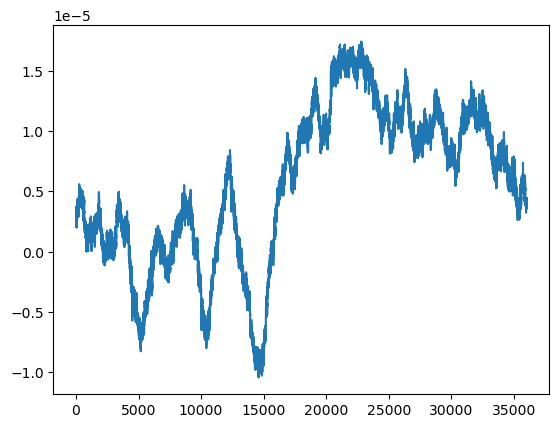

In [10]:
plt.plot(mean_epoch[45])